# Portafolio Cuantitativo Neutral al Mercado

## Extensión: Selección de Pares mediante RMT + TDA

**Autor:** Samuel

**Institución:** Tec de Monterrey

**Área:** Finanzas Cuantitativas, Economía Estadística y Machine Learning

**Notebook base:** `main.ipynb`

---

Este notebook parte del resultado del pipeline original (`main.ipynb`), donde Engle-Granger no encontró pares robustos tras corrección por comparaciones múltiples, Johansen encontró una única relación de cointegración sobre las 12 divisas, y el backtest out-of-sample resultó en pérdidas sostenidas (Sharpe -2.10, CAGR -24.6%).

La hipótesis de trabajo aquí es que el eslabón débil no fue el Kalman, las reglas de ejecución ni el HMM — fue la **selección de la relación de cointegración misma**, probablemente encontrada por azar sobre un universo de comparaciones múltiples sin suficiente filtrado previo.

Este notebook aplica el ajuste propuesto en la retroalimentación inicial del proyecto: limpiar la matriz de correlaciones con **Random Matrix Theory (RMT)** antes de buscar cointegración, y usar **Análisis Topológico de Datos (TDA)** para agrupar divisas candidatas de forma más robusta que probar las 66 combinaciones a ciegas. El resto del pipeline (Kalman, reglas de ejecución, HMM, backtesting) se reutiliza con la misma lógica del notebook original, adaptado a lo que resulte de esta nueva selección.

## Instalación de Librerías

Se instalan las librerías necesarias para este notebook. La Fase 1 (datos) y las Fases 3-5 (Kalman, HMM, backtesting) reutilizan las mismas librerías de `main.ipynb`; lo nuevo aquí es el bloque de RMT + TDA para la Fase 2.

In [2]:
# Fase 1 — Datos (igual que main.ipynb)
# %pip install yfinance pandas numpy

# Fase 2A — Random Matrix Theory (RMT)
# %pip install scipy numpy

# Fase 2B — Análisis Topológico de Datos (TDA)
# %pip install gudhi ripser kmapper scikit-learn networkx

# Fase 2C — Validación econométrica (igual que main.ipynb)
# %pip install statsmodels

# Fase 3 — Filtro de Kalman (igual que main.ipynb)
# %pip install pykalman filterpy

# Fase 4 — Reglas de ejecución + HMM (igual que main.ipynb)
# %pip install hmmlearn

# Fase 5 — Backtesting y métricas (igual que main.ipynb)
# %pip install vectorbt quantstats empyrical-reloaded

## Fase 1: Datos y EDA

Descargamos los precios históricos de las divisas del universo (12 divisas, ~2 años por hora vía yfinance) — misma fuente, mismo universo y misma ventana que en `main.ipynb`, para que el resultado de RMT+TDA sea directamente comparable contra el pipeline original.

In [3]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

In [4]:
pd.set_option('display.max_columns', None)

# Universo de 12 divisas de alta liquidez, expresadas como pares contra USD (formato yfinance)
tickers = {
    'EURUSD': 'EURUSD=X',
    'GBPUSD': 'GBPUSD=X',
    'AUDUSD': 'AUDUSD=X',
    'NZDUSD': 'NZDUSD=X',
    'USDJPY': 'USDJPY=X',
    'USDCAD': 'USDCAD=X',
    'USDCHF': 'USDCHF=X',
    'USDMXN': 'USDMXN=X',
    'USDCNY': 'USDCNY=X',
    'USDSEK': 'USDSEK=X',
    'USDNOK': 'USDNOK=X',
    'USDSGD': 'USDSGD=X',
}

In [5]:
# yfinance limita los intervalos de 60m a los últimos ~730 días
raw_data = yf.download(
    list(tickers.values()),
    period='729d',
    interval='60m',
    progress=False
)['Close']

raw_data.columns = tickers.keys()
raw_data.head()

,EURUSD,GBPUSD,AUDUSD,NZDUSD,USDJPY,USDCAD,USDCHF,USDMXN,USDCNY,USDSEK,USDNOK,USDSGD
Datetime,,,,,,,,,,,,
2023-11-24 00:00:00+00:00,0.656918,1.090988,1.254217,0.605620,1.36928,0.88384,NaN,149.487000,17.178600,10.76342,10.48225,1.33966
2023-11-24 01:00:00+00:00,0.656388,1.090513,1.253306,0.605547,1.36962,0.88417,7.1444,149.516006,17.173800,10.76780,10.49459,1.34051
2023-11-24 02:00:00+00:00,0.655531,1.089918,1.252725,0.604961,1.37071,0.88470,7.1503,149.516998,17.178600,10.78049,10.50455,1.34185
2023-11-24 03:00:00+00:00,0.655837,1.090156,1.253541,0.605180,1.37057,0.88411,7.1493,149.503998,17.177999,10.77965,10.49791,1.34153
2023-11-24 04:00:00+00:00,0.656310,1.090631,1.253840,0.605620,1.37025,0.88393,7.1491,149.343994,17.175301,10.77144,10.49616,1.34118


In [6]:
# Forex opera 24/5; puede haber pequeños huecos entre calendarios de distintos pares.
data = raw_data.copy().ffill().dropna()

print(f"Rango de fechas: {data.index.min()} a {data.index.max()}")
print(f"Número de observaciones: {len(data)}")
data.head()

Rango de fechas: 2023-11-24 01:00:00+00:00 a 2026-09-09 01:00:00+01:00
Número de observaciones: 17352


,EURUSD,GBPUSD,AUDUSD,NZDUSD,USDJPY,USDCAD,USDCHF,USDMXN,USDCNY,USDSEK,USDNOK,USDSGD
Datetime,,,,,,,,,,,,
2023-11-24 01:00:00+00:00,0.656388,1.090513,1.253306,0.605547,1.36962,0.88417,7.1444,149.516006,17.173800,10.76780,10.49459,1.34051
2023-11-24 02:00:00+00:00,0.655531,1.089918,1.252725,0.604961,1.37071,0.88470,7.1503,149.516998,17.178600,10.78049,10.50455,1.34185
2023-11-24 03:00:00+00:00,0.655837,1.090156,1.253541,0.605180,1.37057,0.88411,7.1493,149.503998,17.177999,10.77965,10.49791,1.34153
2023-11-24 04:00:00+00:00,0.656310,1.090631,1.253840,0.605620,1.37025,0.88393,7.1491,149.343994,17.175301,10.77144,10.49616,1.34118
2023-11-24 05:00:00+00:00,0.656987,1.091465,1.254595,0.606061,1.36972,0.88297,7.1503,149.253006,17.169701,10.75993,10.49005,1.34036


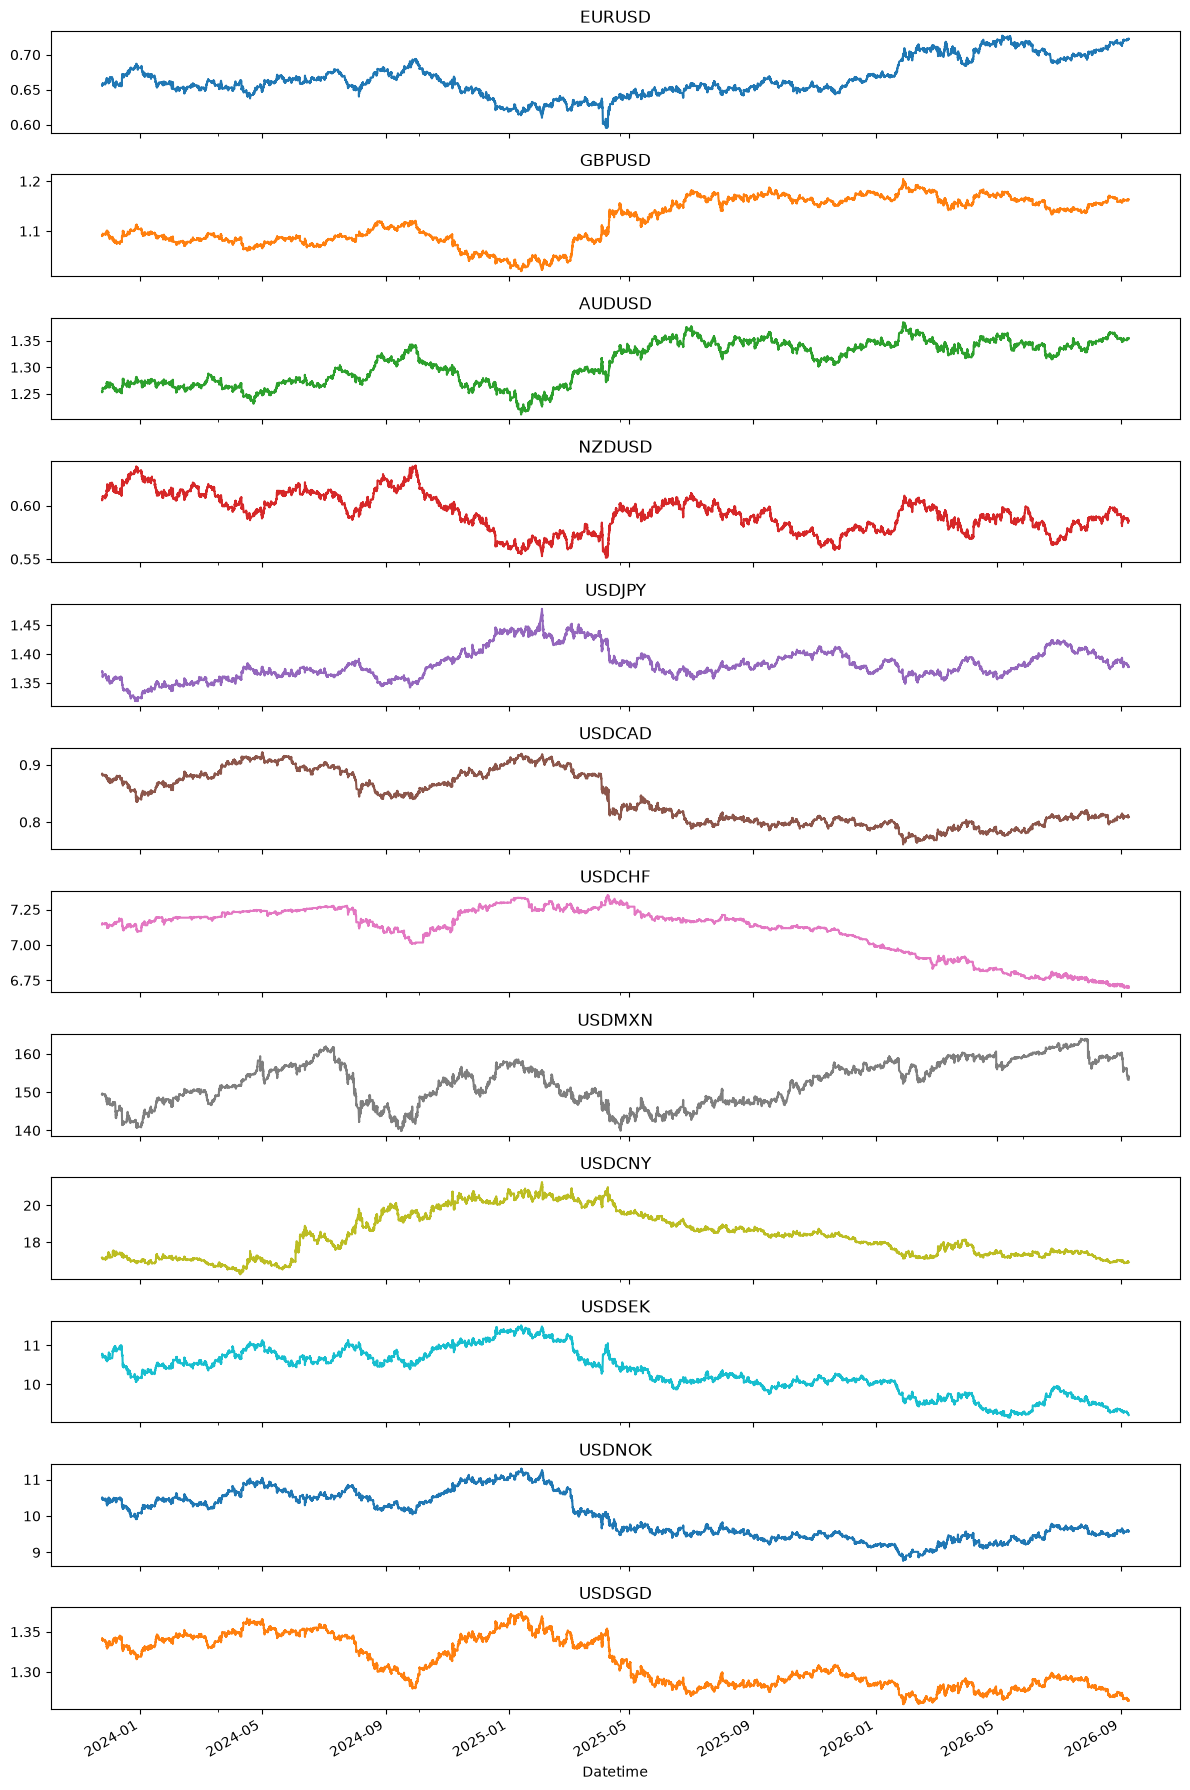

In [7]:
data.plot(subplots=True, figsize=(12, 18), title=list(data.columns), legend=False)
plt.tight_layout()
plt.show()

In [8]:
# Datos de entrenamiento y validacion

split_idx = int(len(data) * 0.70)
train = data.iloc[:split_idx]
test = data.iloc[split_idx:]

print(f"data: {data.shape} | train: {train.shape} | test: {test.shape}")

data: (17352, 12) | train: (12146, 12) | test: (5206, 12)


## Fase 2A: Random Matrix Theory (RMT)

Antes de buscar cointegración, se limpia la matriz de correlaciones del universo de divisas, separando relaciones estadísticamente significativas del "ruido" esperado por azar. Se comparan los eigenvalores empíricos de la matriz de correlación contra la distribución teórica de Marchenko-Pastur (el caso puramente aleatorio); los eigenvalores dentro de ese rango se tratan como ruido y se descartan al reconstruir la matriz.

**Aviso metodológico honesto antes de correr esto:** RMT es más poderoso cuando el número de activos (N) es comparable al número de observaciones (T) — el caso típico son cientos de acciones sobre unos pocos años de datos diarios. Aquí tenemos N=12 divisas contra varios miles de observaciones horarias, es decir, T >> N. En ese régimen, la banda de "ruido" de Marchenko-Pastur es muy angosta, y es probable que **casi todos los eigenvalores aparezcan como "señal"** por la simple razón de que T es grande, no porque las 12 divisas estén genuinamente relacionadas más allá del azar. Vale la pena correr el análisis igual (es información real y correcta), pero no esperes que filtre mucho — su valor aquí es más diagnóstico que un cambio drástico a la matriz.

In [9]:
from scipy import linalg


In [10]:
# RMT se aplica sobre retornos, no sobre niveles de precio (los precios en niveles
# no son estacionarios, y su matriz de correlación estaría dominada por tendencias
# compartidas, no por la estructura de comovimiento real que buscamos filtrar)
log_returns_train = np.log(train / train.shift(1)).dropna()

N = log_returns_train.shape[1]  # número de divisas
T = log_returns_train.shape[0]  # número de observaciones
Q = T / N

print(f"N (divisas): {N}")
print(f"T (observaciones): {T}")
print(f"Q = T/N: {Q:.1f}")

N (divisas): 12
T (observaciones): 12145
Q = T/N: 1012.1


In [11]:
corr_matrix = log_returns_train.corr()

eigenvalues, eigenvectors = linalg.eigh(corr_matrix.values)
# eigh devuelve en orden ascendente; invertimos para tener el mayor primero
eigenvalues = eigenvalues[::-1]
eigenvectors = eigenvectors[:, ::-1]

print("Eigenvalores de la matriz de correlación (de mayor a menor):")
print(np.round(eigenvalues, 4))
print(f"\nSuma de eigenvalores (debe ser ≈ N = {N}): {eigenvalues.sum():.4f}")

Eigenvalores de la matriz de correlación (de mayor a menor):
[6.7255 1.2934 0.9237 0.6508 0.5697 0.4214 0.3885 0.302  0.2391 0.2174
 0.1535 0.1151]

Suma de eigenvalores (debe ser ≈ N = 12): 12.0000


Banda de ruido esperada (Marchenko-Pastur): [0.9381, 1.0639]


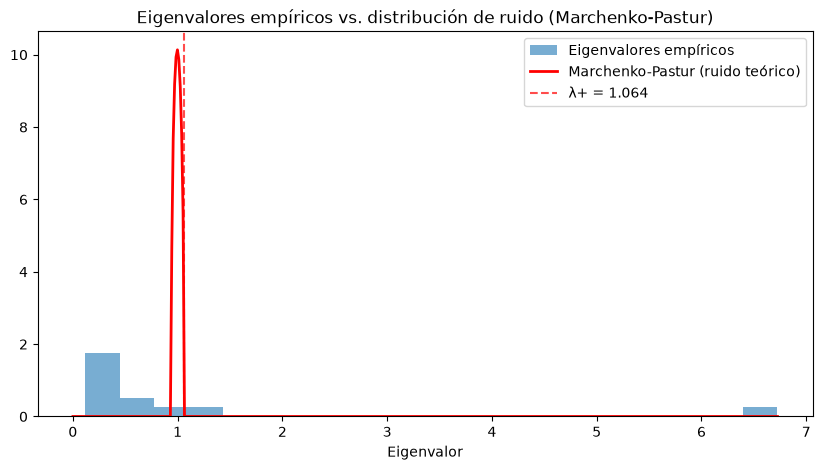


Eigenvalores por encima de λ+ (considerados 'señal'): 2 de 12


In [12]:
def marchenko_pastur_pdf(x, Q, sigma=1.0):
    """Densidad teórica de Marchenko-Pastur para el caso puramente aleatorio (ruido)."""
    lambda_plus = sigma**2 * (1 + np.sqrt(1/Q))**2
    lambda_minus = sigma**2 * (1 - np.sqrt(1/Q))**2
    x = np.asarray(x)
    pdf = np.zeros_like(x)
    mask = (x >= lambda_minus) & (x <= lambda_plus)
    pdf[mask] = (Q / (2 * np.pi * sigma**2 * x[mask])) * np.sqrt((lambda_plus - x[mask]) * (x[mask] - lambda_minus))
    return pdf, lambda_plus, lambda_minus

x_range = np.linspace(0.001, max(eigenvalues.max(), 3), 500)
mp_pdf, lambda_plus, lambda_minus = marchenko_pastur_pdf(x_range, Q)

print(f"Banda de ruido esperada (Marchenko-Pastur): [{lambda_minus:.4f}, {lambda_plus:.4f}]")

plt.figure(figsize=(10, 5))
plt.hist(eigenvalues, bins=20, density=True, alpha=0.6, label='Eigenvalores empíricos')
plt.plot(x_range, mp_pdf, color='red', linewidth=2, label='Marchenko-Pastur (ruido teórico)')
plt.axvline(lambda_plus, color='red', linestyle='--', alpha=0.7, label=f'λ+ = {lambda_plus:.3f}')
plt.legend()
plt.title("Eigenvalores empíricos vs. distribución de ruido (Marchenko-Pastur)")
plt.xlabel("Eigenvalor")
plt.show()

n_signal = (eigenvalues > lambda_plus).sum()
print(f"\nEigenvalores por encima de λ+ (considerados 'señal'): {n_signal} de {N}")

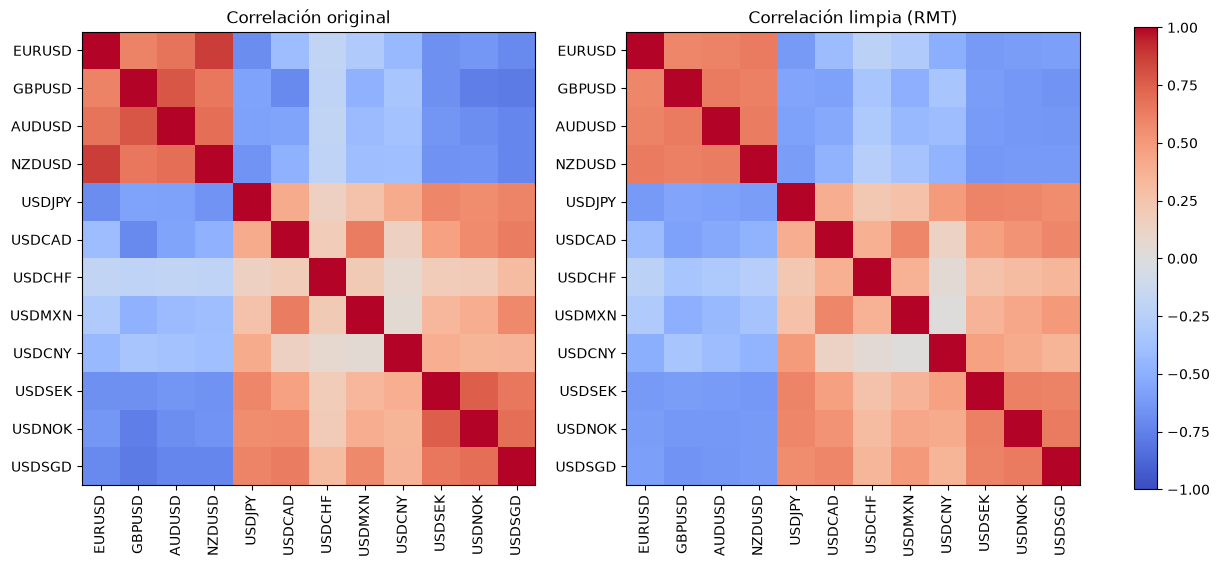

Diferencia promedio |original - limpia|: 0.05954
Diferencia máxima: 0.23321


In [13]:
def clean_correlation_matrix(eigenvalues, eigenvectors, lambda_plus):
    """
    Reconstruye la matriz de correlación conservando solo los componentes de 'señal'
    (eigenvalores > lambda_plus) y reemplazando los de 'ruido' por su promedio,
    preservando la traza (suma de eigenvalores = N).
    """
    n_signal = (eigenvalues > lambda_plus).sum()

    cleaned_eigenvalues = eigenvalues.copy()
    if n_signal < len(eigenvalues):
        noise_avg = eigenvalues[n_signal:].mean()
        cleaned_eigenvalues[n_signal:] = noise_avg

    corr_clean = eigenvectors @ np.diag(cleaned_eigenvalues) @ eigenvectors.T

    # Renormalizar diagonal a 1 (una matriz de correlación siempre tiene diagonal = 1)
    d = np.sqrt(np.diag(corr_clean))
    corr_clean = corr_clean / np.outer(d, d)

    return pd.DataFrame(corr_clean, index=corr_matrix.index, columns=corr_matrix.columns)

corr_clean = clean_correlation_matrix(eigenvalues, eigenvectors, lambda_plus)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
im1 = axes[0].imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
axes[0].set_xticks(range(N)); axes[0].set_xticklabels(corr_matrix.columns, rotation=90)
axes[0].set_yticks(range(N)); axes[0].set_yticklabels(corr_matrix.columns)
axes[0].set_title("Correlación original")

im2 = axes[1].imshow(corr_clean, cmap='coolwarm', vmin=-1, vmax=1)
axes[1].set_xticks(range(N)); axes[1].set_xticklabels(corr_clean.columns, rotation=90)
axes[1].set_yticks(range(N)); axes[1].set_yticklabels(corr_clean.columns)
axes[1].set_title("Correlación limpia (RMT)")

plt.colorbar(im2, ax=axes, fraction=0.03)
plt.show()

diff = (corr_matrix - corr_clean).abs()
print(f"Diferencia promedio |original - limpia|: {diff.values[np.triu_indices(N, k=1)].mean():.5f}")
print(f"Diferencia máxima: {diff.values[np.triu_indices(N, k=1)].max():.5f}")

## Fase 2B: Análisis Topológico de Datos (TDA)

Sobre la matriz de correlación ya limpiada (`corr_clean`), se construye una matriz de distancias y se calcula homología persistente vía un complejo de Vietoris-Rips. El objetivo es identificar clusters de divisas (H₀) que se agrupan de forma más matizada que el factor único dominante detectado por RMT, y detectar relaciones cíclicas (H₁) que un clustering jerárquico simple no revelaría.

In [18]:
import gudhi
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

In [15]:
# Conversión estándar de correlación a distancia (Mantegna, 1999):
# correlación 1 (idénticas) -> distancia 0; correlación -1 (opuestas) -> distancia 2
distance_matrix = np.sqrt(2 * (1 - corr_clean.values))
np.fill_diagonal(distance_matrix, 0)

distance_df = pd.DataFrame(distance_matrix, index=corr_clean.index, columns=corr_clean.columns)
distance_df.round(3)

,EURUSD,GBPUSD,AUDUSD,NZDUSD,USDJPY,USDCAD,USDCHF,USDMXN,USDCNY,USDSEK,USDNOK,USDSGD
EURUSD,0.000,0.914,0.885,0.853,1.799,1.682,1.566,1.606,1.736,1.802,1.793,1.782
GBPUSD,0.914,0.000,0.856,0.880,1.764,1.778,1.638,1.732,1.638,1.790,1.805,1.817
AUDUSD,0.885,0.856,0.000,0.865,1.778,1.750,1.617,1.694,1.673,1.797,1.805,1.809
NZDUSD,0.853,0.880,0.865,0.000,1.794,1.715,1.590,1.648,1.712,1.804,1.802,1.798
USDJPY,1.799,1.764,1.778,1.794,0.000,1.103,1.255,1.207,1.010,0.897,0.916,0.936
USDCAD,1.682,1.778,1.750,1.715,1.103,0.000,1.116,0.910,1.321,1.034,0.973,0.918
USDCHF,1.566,1.638,1.617,1.590,1.255,1.116,0.000,1.124,1.382,1.215,1.180,1.149
USDMXN,1.606,1.732,1.694,1.648,1.207,0.910,1.124,0.000,1.414,1.136,1.068,1.006
USDCNY,1.736,1.638,1.673,1.712,1.010,1.321,1.382,1.414,0.000,1.044,1.095,1.140
USDSEK,1.802,1.790,1.797,1.804,0.897,1.034,1.215,1.136,1.044,0.000,0.879,0.886


Número de simplejos en el complejo: 298
Número de features topológicas encontradas: 13


c:\Users\samyo\OneDrive\Documentos\GitHub\Investigacion_PCNM\.venv-312-Investigacion_PCNM\Lib\site-packages\gudhi\persistence_graphical_tools.py:155: UserWarning: usetex mode requires TeX.
  warnings.warn("usetex mode requires TeX.")


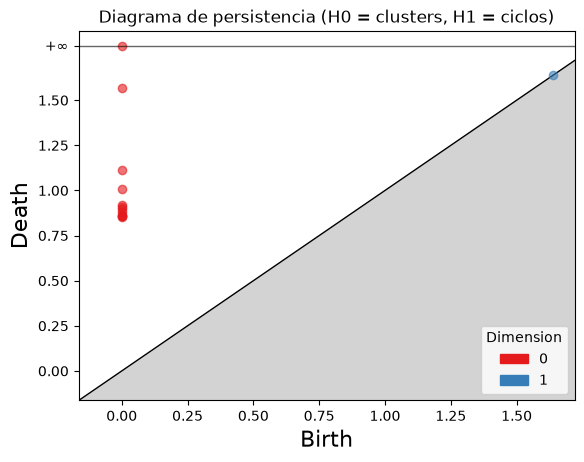

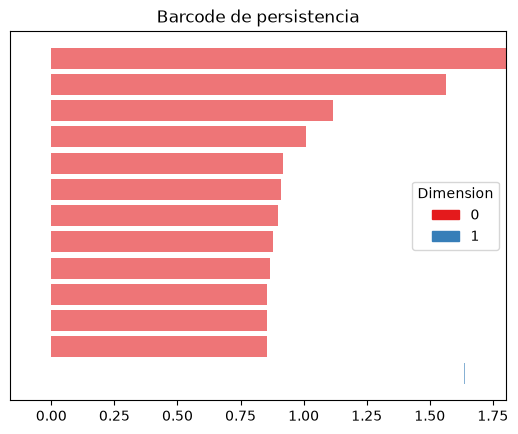

In [17]:
rips_complex = gudhi.RipsComplex(distance_matrix=distance_matrix, max_edge_length=2.0)
simplex_tree = rips_complex.create_simplex_tree(max_dimension=2)

persistence = simplex_tree.persistence()

print(f"Número de simplejos en el complejo: {simplex_tree.num_simplices()}")
print(f"Número de features topológicas encontradas: {len(persistence)}")

gudhi.plot_persistence_diagram(persistence)
plt.title("Diagrama de persistencia (H0 = clusters, H1 = ciclos)")
plt.show()

gudhi.plot_persistence_barcode(persistence)
plt.title("Barcode de persistencia")
plt.show()

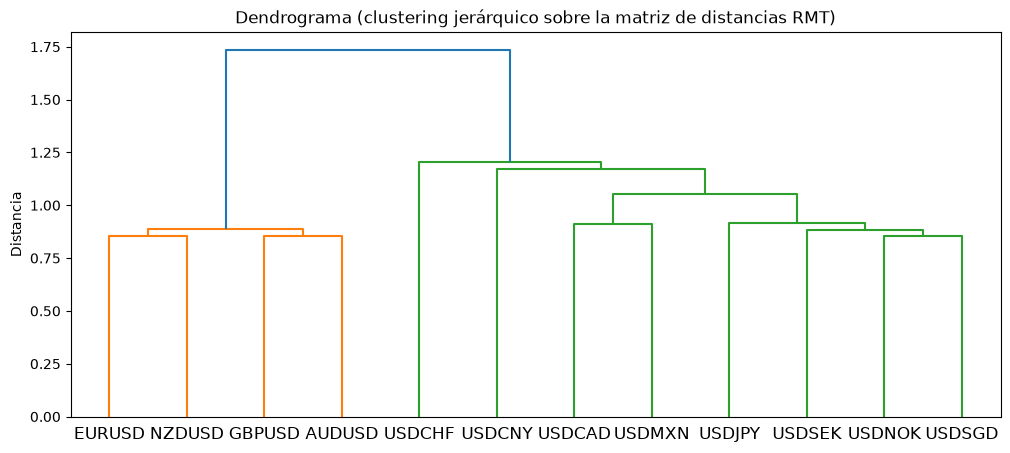

In [19]:
condensed_dist = squareform(distance_matrix, checks=False)
Z = linkage(condensed_dist, method='average')

plt.figure(figsize=(12, 5))
dendrogram(Z, labels=corr_clean.columns.tolist())
plt.title("Dendrograma (clustering jerárquico sobre la matriz de distancias RMT)")
plt.ylabel("Distancia")
plt.show()

In [20]:
# Cortamos a una distancia menor que la que separa los dos bloques dominados por USD (~1.73),
# para capturar la estructura MÁS FINA dentro de cada bloque, no solo la separación por convención de cotización
cluster_labels = fcluster(Z, t=1.0, criterion='distance')

clusters_df = pd.DataFrame({'divisa': corr_clean.columns, 'cluster': cluster_labels})
clusters_df = clusters_df.sort_values('cluster')
print(clusters_df)

print(f"\nNúmero de clusters: {clusters_df['cluster'].nunique()}")
clusters_df.groupby('cluster')['divisa'].apply(list)

    divisa  cluster
0   EURUSD        1
1   GBPUSD        1
2   AUDUSD        1
3   NZDUSD        1
5   USDCAD        2
7   USDMXN        2
4   USDJPY        3
9   USDSEK        3
11  USDSGD        3
10  USDNOK        3
8   USDCNY        4
6   USDCHF        5

Número de clusters: 5


cluster
1    [EURUSD, GBPUSD, AUDUSD, NZDUSD]
2                    [USDCAD, USDMXN]
3    [USDJPY, USDSEK, USDSGD, USDNOK]
4                            [USDCNY]
5                            [USDCHF]
Name: divisa, dtype: object

## Fase 2C: Validación Econométrica Dirigida por los Clusters

En vez de probar las 66 combinaciones posibles entre las 12 divisas (como en `main.ipynb`), se corre Engle-Granger y Johansen **solo dentro de cada cluster** encontrado por TDA. Los clusters de un solo elemento (USDCNY, USDCHF) se excluyen de Engle-Granger por no tener con quién formar par, pero se mantienen en observación para Johansen si se decide ampliar el análisis más adelante.

Esto reduce el número de pruebas de 66 a 13 (6 del cluster 1, 1 del cluster 2, 6 del cluster 3), lo cual relaja de forma legítima el umbral de corrección por comparaciones múltiples — no porque bajemos el estándar, sino porque genuinamente estamos haciendo muchas menos comparaciones.

In [23]:
from itertools import combinations
from statsmodels.tsa.stattools import coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.stats.multitest import multipletests

In [24]:
def johansen_test(data: pd.DataFrame, det_order: int = 0, k_ar_diff: int = 1):
    """
    Prueba de Johansen sobre el universo (o cluster) dado.
    det_order=0: sin tendencia determinista. k_ar_diff: rezagos en diferencias.
    """
    result = coint_johansen(data, det_order, k_ar_diff)
    trace_stat = result.lr1
    crit_vals_95 = result.cvt[:, 1]
    n_relations = sum(trace_stat > crit_vals_95)
    return pd.DataFrame({
        'trace_stat': trace_stat,
        'crit_val_95': crit_vals_95,
        'cointegrado': trace_stat > crit_vals_95,
    }), n_relations

In [21]:
clusters = clusters_df.groupby('cluster')['divisa'].apply(list).to_dict()

for cid, members in clusters.items():
    print(f"Cluster {cid}: {members}")

Cluster 1: ['EURUSD', 'GBPUSD', 'AUDUSD', 'NZDUSD']
Cluster 2: ['USDCAD', 'USDMXN']
Cluster 3: ['USDJPY', 'USDSEK', 'USDSGD', 'USDNOK']
Cluster 4: ['USDCNY']
Cluster 5: ['USDCHF']


In [25]:
def engle_granger_within_clusters(data: pd.DataFrame, clusters: dict) -> pd.DataFrame:
    results = []
    for cid, members in clusters.items():
        if len(members) < 2:
            continue  # cluster de un solo elemento, no hay par que probar
        for asset1, asset2 in combinations(members, 2):
            score, p_value, _ = coint(data[asset1], data[asset2])
            results.append({
                'cluster': cid,
                'par': f"{asset1}-{asset2}",
                'asset1': asset1,
                'asset2': asset2,
                'p_value': p_value,
            })
    return pd.DataFrame(results).sort_values('p_value').reset_index(drop=True)

eg_clustered = engle_granger_within_clusters(train, clusters)
print(f"Número de pares probados: {len(eg_clustered)}  (vs. 66 en main.ipynb)")
eg_clustered

Número de pares probados: 13  (vs. 66 en main.ipynb)


,cluster,par,asset1,asset2,p_value
0,3,USDSEK-USDNOK,USDSEK,USDNOK,0.082468
1,1,EURUSD-GBPUSD,EURUSD,GBPUSD,0.365063
2,1,EURUSD-AUDUSD,EURUSD,AUDUSD,0.366489
3,3,USDSEK-USDSGD,USDSEK,USDSGD,0.382329
4,1,GBPUSD-AUDUSD,GBPUSD,AUDUSD,0.423770
5,3,USDSGD-USDNOK,USDSGD,USDNOK,0.595208
6,1,AUDUSD-NZDUSD,AUDUSD,NZDUSD,0.663305
7,3,USDJPY-USDSGD,USDJPY,USDSGD,0.780775
8,1,EURUSD-NZDUSD,EURUSD,NZDUSD,0.794499
9,3,USDJPY-USDNOK,USDJPY,USDNOK,0.802676


In [26]:
n_tests_clustered = len(eg_clustered)
bonferroni_alpha_clustered = 0.05 / n_tests_clustered

eg_clustered['cointegrado_bonferroni'] = eg_clustered['p_value'] < bonferroni_alpha_clustered

rejected_fdr, p_adj_fdr, _, _ = multipletests(eg_clustered['p_value'], alpha=0.05, method='fdr_bh')
eg_clustered['p_value_fdr'] = p_adj_fdr
eg_clustered['cointegrado_fdr'] = rejected_fdr

print(f"Umbral Bonferroni ajustado: {bonferroni_alpha_clustered:.5f}  (vs. {0.05/66:.5f} en main.ipynb)")
print(f"Pares que sobreviven Bonferroni: {eg_clustered['cointegrado_bonferroni'].sum()}")
print(f"Pares que sobreviven FDR: {eg_clustered['cointegrado_fdr'].sum()}")

eg_clustered

Umbral Bonferroni ajustado: 0.00385  (vs. 0.00076 en main.ipynb)
Pares que sobreviven Bonferroni: 0
Pares que sobreviven FDR: 0


,cluster,par,asset1,asset2,p_value,cointegrado_bonferroni,p_value_fdr,cointegrado_fdr
0,3,USDSEK-USDNOK,USDSEK,USDNOK,0.082468,False,0.959383,False
1,1,EURUSD-GBPUSD,EURUSD,GBPUSD,0.365063,False,0.959383,False
2,1,EURUSD-AUDUSD,EURUSD,AUDUSD,0.366489,False,0.959383,False
3,3,USDSEK-USDSGD,USDSEK,USDSGD,0.382329,False,0.959383,False
4,1,GBPUSD-AUDUSD,GBPUSD,AUDUSD,0.423770,False,0.959383,False
5,3,USDSGD-USDNOK,USDSGD,USDNOK,0.595208,False,0.959383,False
6,1,AUDUSD-NZDUSD,AUDUSD,NZDUSD,0.663305,False,0.959383,False
7,3,USDJPY-USDSGD,USDJPY,USDSGD,0.780775,False,0.959383,False
8,1,EURUSD-NZDUSD,EURUSD,NZDUSD,0.794499,False,0.959383,False
9,3,USDJPY-USDNOK,USDJPY,USDNOK,0.802676,False,0.959383,False


In [28]:
johansen_by_cluster = {}

for cid, members in clusters.items():
    if len(members) < 3:
        continue  # Johansen necesita al menos 3 series para ser más informativo que Engle-Granger
    print(f"\n--- Cluster {cid}: {members} ---")
    for lag in [1, 4, 12, 24, 48]:
        result_df, n_rel = johansen_test(train[members], k_ar_diff=lag)
        print(f"  k_ar_diff={lag:>2} -> relaciones detectadas: {n_rel}")
    johansen_by_cluster[cid] = members


--- Cluster 1: ['EURUSD', 'GBPUSD', 'AUDUSD', 'NZDUSD'] ---
  k_ar_diff= 1 -> relaciones detectadas: 0
  k_ar_diff= 4 -> relaciones detectadas: 0
  k_ar_diff=12 -> relaciones detectadas: 0
  k_ar_diff=24 -> relaciones detectadas: 0
  k_ar_diff=48 -> relaciones detectadas: 0

--- Cluster 3: ['USDJPY', 'USDSEK', 'USDSGD', 'USDNOK'] ---
  k_ar_diff= 1 -> relaciones detectadas: 1
  k_ar_diff= 4 -> relaciones detectadas: 1
  k_ar_diff=12 -> relaciones detectadas: 1
  k_ar_diff=24 -> relaciones detectadas: 1
  k_ar_diff=48 -> relaciones detectadas: 1


In [29]:
cluster3_members = clusters[3]  # ['USDJPY', 'USDSEK', 'USDSGD', 'USDNOK']

log_train_c3 = np.log(train[cluster3_members])

print("--- Johansen sobre log-precios, Cluster 3 ---")
for lag in [1, 4, 12, 24, 48]:
    result_df, n_rel = johansen_test(log_train_c3, k_ar_diff=lag)
    print(f"k_ar_diff={lag:>2} -> relaciones detectadas: {n_rel}")

--- Johansen sobre log-precios, Cluster 3 ---
k_ar_diff= 1 -> relaciones detectadas: 1
k_ar_diff= 4 -> relaciones detectadas: 1
k_ar_diff=12 -> relaciones detectadas: 1
k_ar_diff=24 -> relaciones detectadas: 1
k_ar_diff=48 -> relaciones detectadas: 1


In [30]:
best_lag_c3 = 12  # ajusta al rezago que prefieras de los que salieron con relación=1

johansen_full_c3 = coint_johansen(log_train_c3, det_order=0, k_ar_diff=best_lag_c3)
coint_vector_c3 = np.real(johansen_full_c3.evec[:, 0]).astype(np.float64)

weights_c3 = pd.Series(coint_vector_c3, index=cluster3_members).sort_values(key=abs, ascending=False)
print(weights_c3)

USDSEK   -102.394465
USDNOK     78.692798
USDJPY     57.684720
USDSGD    -43.131696
dtype: float64


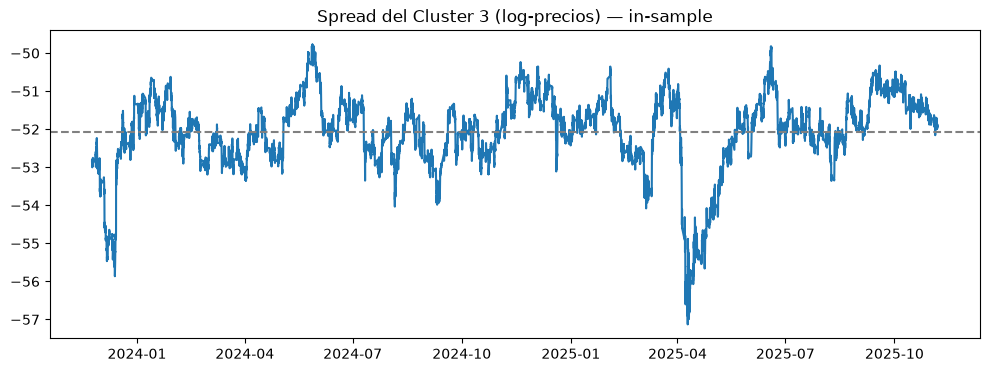

In [31]:
# Confirmar que seguimos en consistencia log-precios para el spread
log_train_c3_check = np.log(train[cluster3_members])
spread_train_c3 = log_train_c3_check @ coint_vector_c3

plt.figure(figsize=(12, 4))
plt.plot(spread_train_c3.index, spread_train_c3.values)
plt.axhline(spread_train_c3.mean(), color='gray', linestyle='--')
plt.title("Spread del Cluster 3 (log-precios) — in-sample")
plt.show()

## Fase 3: Filtro de Kalman (Cluster 3, log-precios)

Se aplica el Filtro de Kalman como modelo de nivel local sobre el spread del Cluster 3 (USDJPY, USDSEK, USDSGD, USDNOK, en log-precios). Con base en la lección de `main.ipynb`, se fija `transition_covariance` en un valor pequeño desde el inicio (en vez de dejarlo libre en el EM), para evitar que el nivel de equilibrio "persiga" al spread en vez de representar un equilibrio lento y estable.

In [34]:
from pykalman import KalmanFilter

Ratio Q/R: 0.17282475394754354


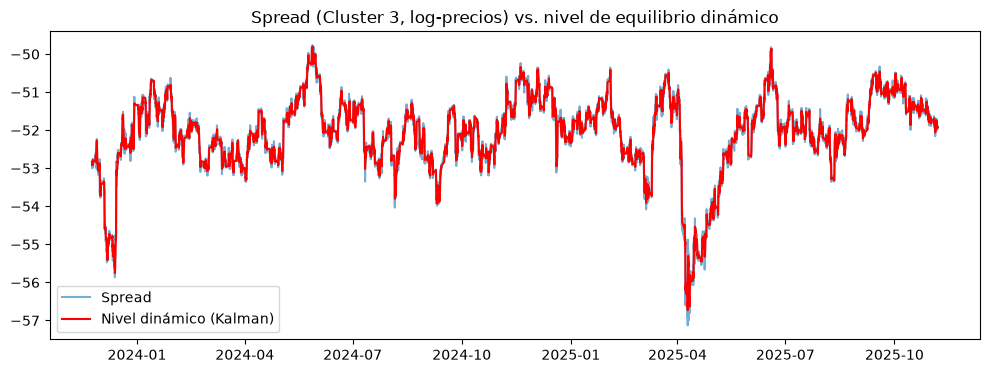

In [35]:
kf_c3 = KalmanFilter(
    transition_matrices=[1],
    observation_matrices=[1],
    initial_state_mean=spread_train_c3.iloc[0],
    initial_state_covariance=1,
    observation_covariance=1,
    transition_covariance=0.001,
)

kf_c3 = kf_c3.em(spread_train_c3.values, n_iter=10, em_vars=['observation_covariance'])

print("Ratio Q/R:", (kf_c3.transition_covariance / kf_c3.observation_covariance)[0][0])

state_means_c3, _ = kf_c3.filter(spread_train_c3.values)
mu_t_train_c3 = pd.Series(state_means_c3.flatten(), index=spread_train_c3.index)

plt.figure(figsize=(12, 4))
plt.plot(spread_train_c3.index, spread_train_c3.values, label='Spread', alpha=0.6)
plt.plot(mu_t_train_c3.index, mu_t_train_c3.values, label='Nivel dinámico (Kalman)', color='red')
plt.legend()
plt.title("Spread (Cluster 3, log-precios) vs. nivel de equilibrio dinámico")
plt.show()

% del tiempo con |Z| >= 2.0: 6.4%


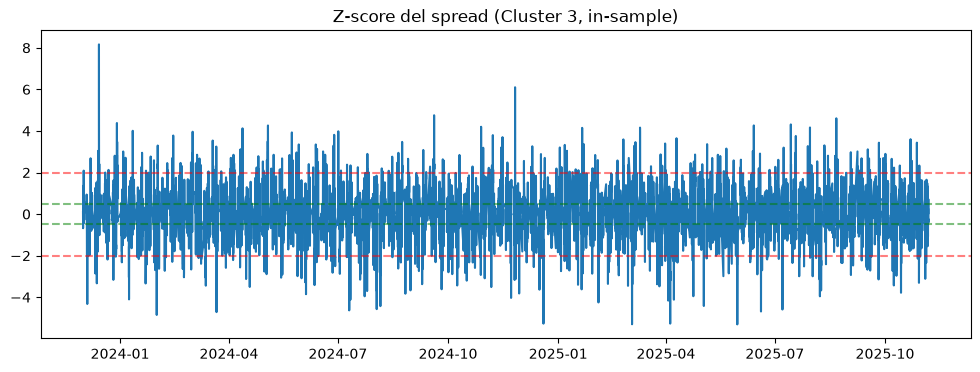

count    12027.000000
mean         0.000724
std          1.024744
min         -5.308459
25%         -0.518887
50%          0.011401
75%          0.530853
max          8.164950
dtype: float64

In [36]:
window = 24 * 5  # 5 días de datos horarios, igual que en main.ipynb

residual_train_c3 = spread_train_c3 - mu_t_train_c3
rolling_std_train_c3 = residual_train_c3.rolling(window).std()
z_score_train_c3 = residual_train_c3 / rolling_std_train_c3

pct_entrada_c3 = (z_score_train_c3.abs() >= 2.0).mean() * 100
print(f"% del tiempo con |Z| >= 2.0: {pct_entrada_c3:.1f}%")

plt.figure(figsize=(12, 4))
plt.plot(z_score_train_c3.index, z_score_train_c3.values)
plt.axhline(2, color='red', linestyle='--', alpha=0.5)
plt.axhline(-2, color='red', linestyle='--', alpha=0.5)
plt.axhline(0.5, color='green', linestyle='--', alpha=0.5)
plt.axhline(-0.5, color='green', linestyle='--', alpha=0.5)
plt.title("Z-score del spread (Cluster 3, in-sample)")
plt.show()

z_score_train_c3.describe()

## Fase 4: Reglas de Ejecución y Gestión de Riesgo (Cluster 3)

Misma lógica que `main.ipynb`: generación de posiciones a partir del Z-score, con un filtro de régimen HMM que reduce el tamaño de posición en periodos de alta volatilidad. Se reutiliza `generate_positions` sin cambios; el HMM se reentrena sobre la volatilidad del nuevo spread.

In [39]:
from hmmlearn.hmm import GaussianHMM

In [38]:
def generate_positions(z_score: pd.Series, entry: float = 2.0, exit: float = 0.5, stop_loss: float = 3.5) -> pd.Series:
    position = 0
    positions = []
    for z in z_score:
        if position == 0:
            if z >= entry:
                position = -1
            elif z <= -entry:
                position = 1
        elif position == 1:
            if z >= -exit or z <= -stop_loss:
                position = 0
        elif position == -1:
            if z <= exit or z >= stop_loss:
                position = 0
        positions.append(position)
    return pd.Series(positions, index=z_score.index, name='position')

positions_train_c3 = generate_positions(z_score_train_c3)

print(positions_train_c3.value_counts())
print(f"\nNúmero de operaciones (cambios de posición desde 0): {(positions_train_c3.diff().abs() > 0).sum()}")

position
 0    10591
-1      788
 1      767
Name: count, dtype: int64

Número de operaciones (cambios de posición desde 0): 900


In [40]:
spread_returns_train_c3 = spread_train_c3.diff().dropna()
realized_vol_train_c3 = spread_returns_train_c3.rolling(24).std().dropna()
log_vol_train_c3 = np.log(realized_vol_train_c3.replace(0, np.nan)).dropna()

hmm_model_c3 = GaussianHMM(n_components=2, covariance_type='diag', n_iter=1000, random_state=42)
hmm_model_c3.fit(log_vol_train_c3.values.reshape(-1, 1))

# Matriz de transición "pegajosa" — la lección aprendida en main.ipynb para evitar
# que el régimen cambie cada pocas horas en vez de detectar tramos persistentes
hmm_model_c3.transmat_ = np.array([[0.98, 0.02], [0.02, 0.98]])

regimes_train_c3 = pd.Series(hmm_model_c3.predict(log_vol_train_c3.values.reshape(-1, 1)), index=log_vol_train_c3.index)
means_c3 = hmm_model_c3.means_.flatten()
high_vol_state_c3 = int(np.argmax(means_c3))
regime_label_train_c3 = regimes_train_c3.map({high_vol_state_c3: 'alta_volatilidad', 1 - high_vol_state_c3: 'calmo'})

print(regime_label_train_c3.value_counts(normalize=True) * 100)

regime_runs_c3 = (regime_label_train_c3 != regime_label_train_c3.shift()).cumsum()
run_lengths_c3 = regime_label_train_c3.groupby(regime_runs_c3).size()
print("\nDuración de rachas de régimen:")
print(run_lengths_c3.describe())

calmo               52.524336
alta_volatilidad    47.475664
Name: proportion, dtype: float64

Duración de rachas de régimen:
count    286.000000
mean      42.384615
std       37.496933
min        4.000000
25%       20.000000
50%       30.500000
75%       52.750000
max      354.000000
dtype: float64


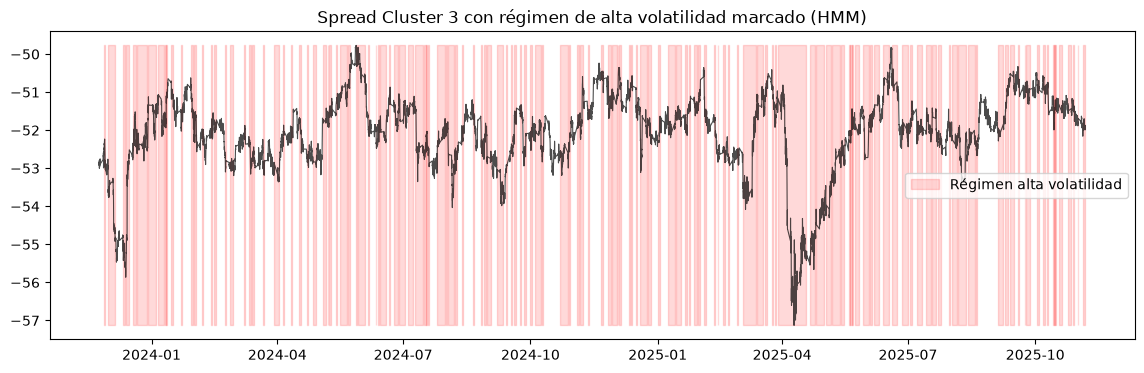

In [41]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(spread_train_c3.index, spread_train_c3.values, color='black', alpha=0.7, linewidth=0.8)

alta_vol_mask_c3 = regime_label_train_c3.reindex(spread_train_c3.index) == 'alta_volatilidad'
ax.fill_between(spread_train_c3.index, spread_train_c3.min(), spread_train_c3.max(),
                 where=alta_vol_mask_c3.fillna(False), color='red', alpha=0.15, label='Régimen alta volatilidad')

ax.set_title("Spread Cluster 3 con régimen de alta volatilidad marcado (HMM)")
ax.legend()
plt.show()